## Part 1: Univariate Analysis
In this section, we will analyze individual columns to see their overall distribution, spread, and frequency across the league history.

In [22]:
# CELL 1: Import tools and load the cleaned dataset explicitly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set visual layouts for graphs later
sns.set_theme(style="whitegrid")

# Tell your new file to read the clean CSV file we saved earlier
df = pd.read_csv('nba_cleaned_dataset.csv')

# Verify that the new file successfully recognizes the data
print("Data successfully loaded into the new file!")
print("Dataset Shape:", df.shape)
df.head()

Data successfully loaded into the new file!
Dataset Shape: (13391, 44)


,normalized_name,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,points,...,value_over_replacement_player,box_plus_minus,draft_year_numeric,draft_round_numeric,draft_number_numeric,scoring_tier,points_log,assists_log,rebounds_log,player_bmi
0,Allen Iverson,26,183.58,74.61,Georgetown,USA,1996,1,1,31.1,...,6.1,6.1,1996.0,1.0,1.0,Elite Scorer (20+ PPG),3.468856,1.722767,1.568616,22.1
1,Jerry Stackhouse,26,198.15,99.23,North Carolina,USA,1995,1,3,29.8,...,5.8,5.1,1995.0,1.0,3.0,Elite Scorer (20+ PPG),3.427515,1.808289,1.589235,25.3
2,Shaquille O'Neal,29,216.31,142.56,Louisiana State,USA,1992,1,1,28.7,...,7.1,7.7,1992.0,1.0,1.0,Elite Scorer (20+ PPG),3.391147,1.547563,2.617396,30.5
3,Kobe Bryant,22,201.60,95.20,No College,USA,1996,1,13,28.5,...,4.7,4.8,1996.0,1.0,13.0,Elite Scorer (20+ PPG),3.384390,1.791759,1.931521,23.4
4,Vince Carter,24,198.64,102.34,North Carolina,USA,1998,1,5,27.6,...,7.2,7.6,1998.0,1.0,5.0,Elite Scorer (20+ PPG),3.353407,1.589235,1.871802,25.9


(Insight to look for: Is the distribution curve perfectly symmetrical, or is it skewed toward a specific side? This tells you if the "average" player height is shifting.)

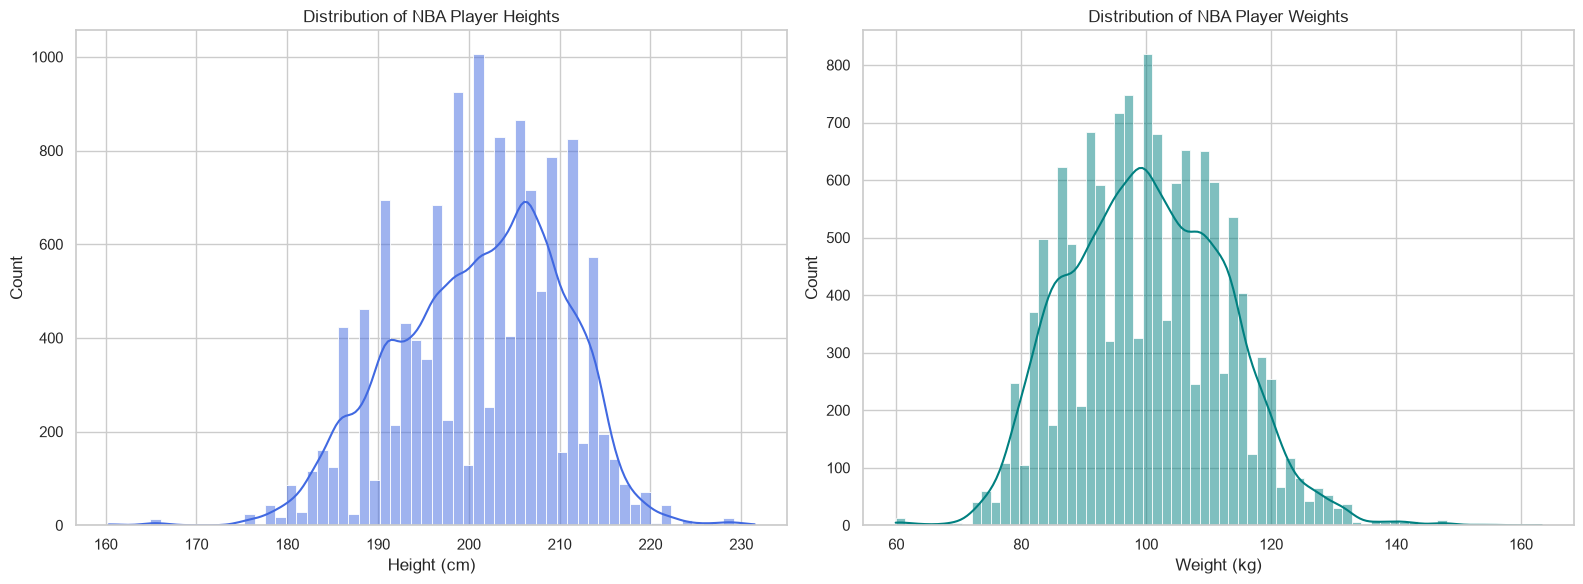

In [23]:
#plotting height distribution 
# Set up a beautiful subplot canvas for two physical metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Height Distribution Histogram
sns.histplot(data=df, x='player_height', kde=True, color='royalblue', ax=axes[0])
axes[0].set_title('Distribution of NBA Player Heights')
axes[0].set_xlabel('Height (cm)')
axes[0].set_ylabel('Count')

# Plot 2: Weight Distribution Histogram
sns.histplot(data=df, x='player_weight', kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribution of NBA Player Weights')
axes[1].set_xlabel('Weight (kg)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Part 2: Bivariate Analysis (Comparing two columns)
how two different metrics relate to each other.

### 1 rebound per game across different position 

C:\Users\pc\AppData\Local\Temp\ipykernel_6296\4294265967.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='position', y='rebounds', palette='Set2')


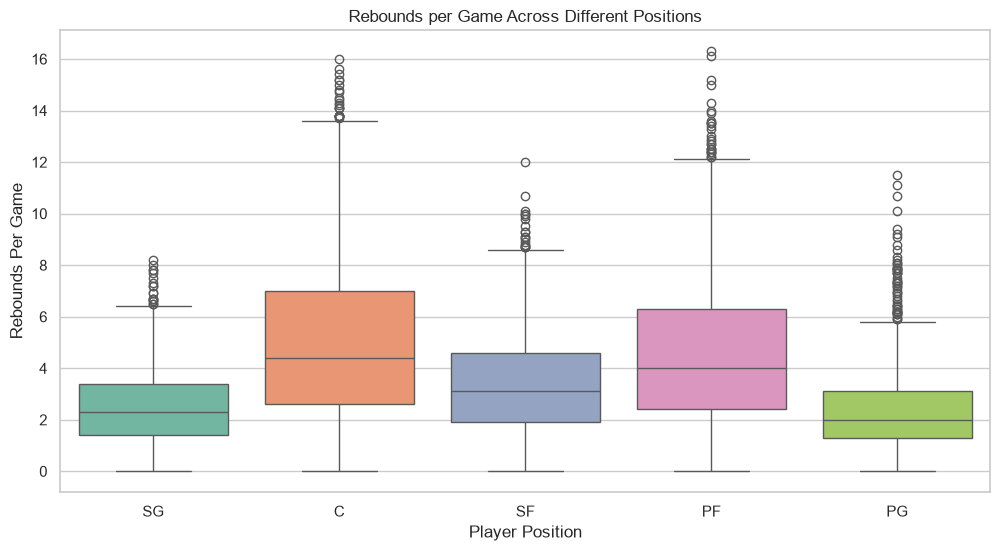

In [24]:
# A boxplot lets us see how a numerical column (rebounds) distributes across a categorical column (position)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='position', y='rebounds', palette='Set2')
plt.title('Rebounds per Game Across Different Positions')
plt.xlabel('Player Position')
plt.ylabel('Rebounds Per Game')
plt.show()

 Quick Insights: Rebounds per Game by PositionThe Height Hierarchy: Rebounding performance directly follows a strict physical size ladder:$$\text{Center (C)} > \text{Power Forward (PF)} > \text{Small Forward (SF)} > \text{Shooting Guard (SG)} > \text{Point Guard (PG)}$$Interior Dominance ($\text{C}$ & $\text{PF}$): Centers ($\text{C}$) dominate the league with the highest median of $4.4$ rebounds, closely followed by Power Forwards ($\text{PF}$) at $4.0$. Their boxes sit noticeably higher on the $y$-axis.Perimeter Drop-off ($\text{SG}$ & $\text{PG}$): Point Guards ($\text{PG}$) record the lowest baseline with a median of just $2.0$ rebounds, reflecting their role away from the basket.Generational Outliers (Floating Dots): The dots above the whiskers highlight exceptional individual seasons. While a typical guard captures around $2$ to $3$ rebounds, historical outliers (like Russell Westbrook) completely break the mold, soaring up to $11.5$ rebounds per game and matching elite Centers.

### 2 Engineered Feature Analysis — Scoring Tiers vs. Game Time
In this section, we analyze the `scoring_tier` column created using NumPy vector operations. We want to see how a player's strategic scoring role matches up against their actual playing time (`minutes_played`).

C:\Users\pc\AppData\Local\Temp\ipykernel_6296\125383498.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


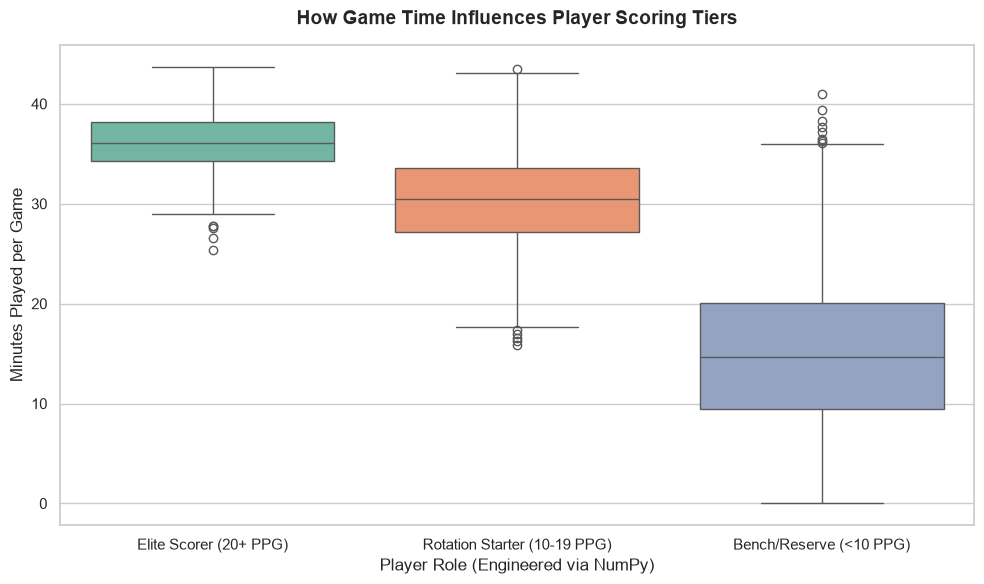

In [31]:
plt.figure(figsize=(10, 6))

# Clean boxplot using the 'scoring_tier' you created with NumPy
sns.boxplot(
    data=df, 
    x='scoring_tier', 
    y='minutes_played', 
    palette='Set2',
    order=['Elite Scorer (20+ PPG)', 'Rotation Starter (10-19 PPG)', 'Bench/Reserve (<10 PPG)']
)

plt.title('How Game Time Influences Player Scoring Tiers', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Player Role (Engineered via NumPy)', fontsize=12)
plt.ylabel('Minutes Played per Game', fontsize=12)

plt.tight_layout()
plt.show()

## Part 3: Advanced Correlation Matrix (The Portfolio Showstopper)
which stats move together (values close to 1 mean strong positive correlation; values close to -1 mean strong inverse correlation).


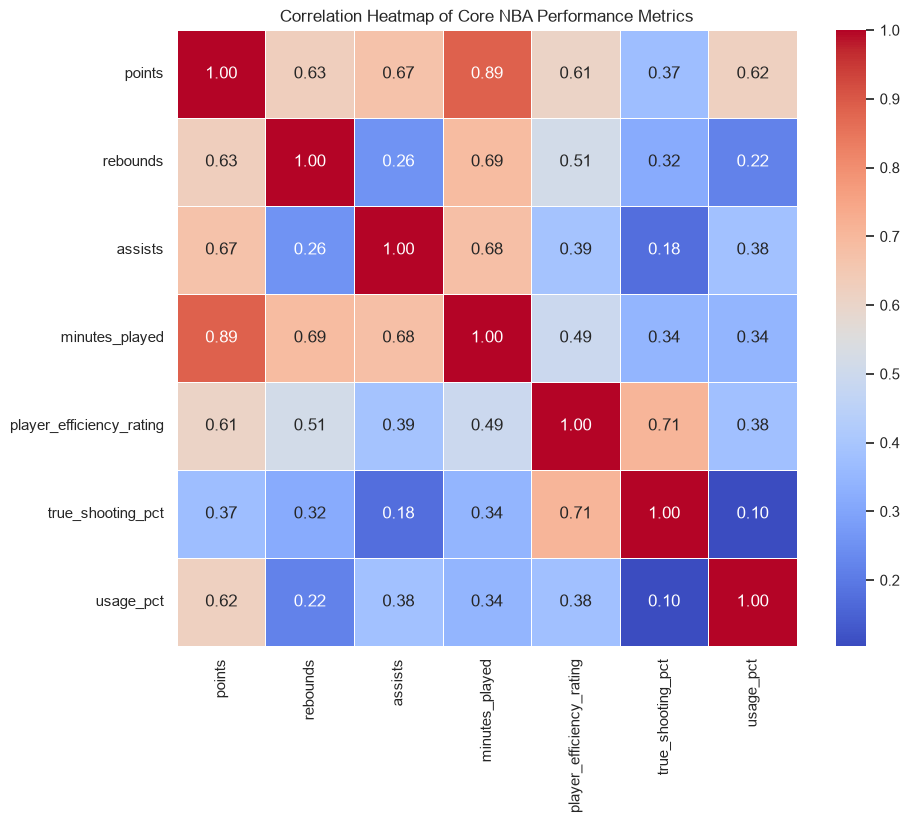

In [25]:
# Select core performance metrics to find correlations
metric_cols = ['points', 'rebounds', 'assists', 'minutes_played', 'player_efficiency_rating', 'true_shooting_pct', 'usage_pct']
corr_matrix = df[metric_cols].corr()

# Draw the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Core NBA Performance Metrics')
plt.show()

## Phase 3: Bivariate & Multivariate Deep Dives
Now we will look at how multiple variables interact simultaneously. We want to answer:
1. Does player height dictate whether they are an asset in assists vs. rebounds?
2. Do players become more efficient (`true_shooting_pct`) when they take on a higher offensive workload (`usage_pct`)?

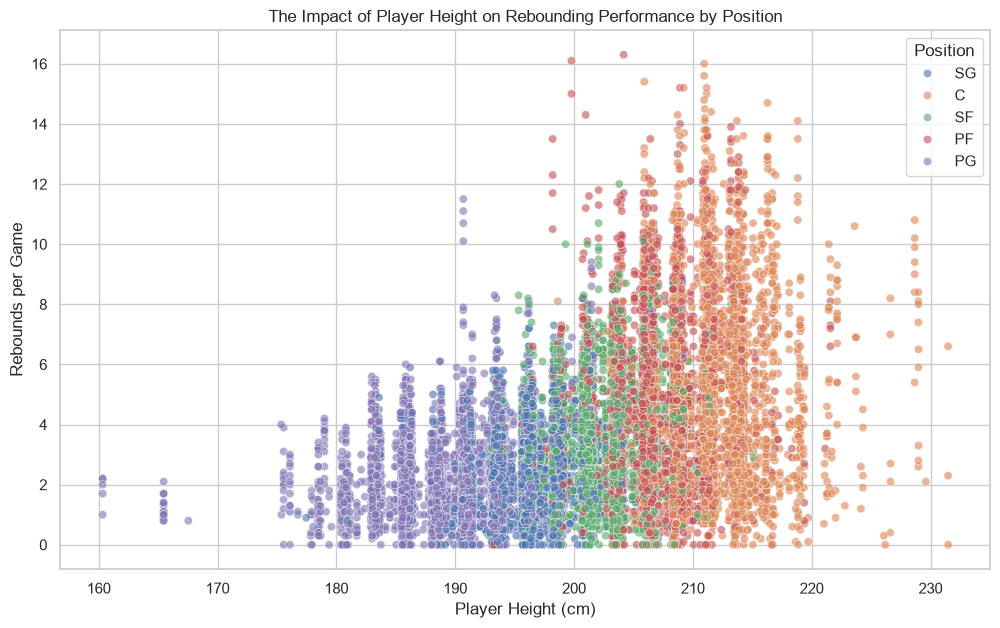

In [26]:
plt.figure(figsize=(12, 7))
# Filtering out positions with rare entries to keep the plot clean
main_positions = df[df['position'].isin(['PG', 'SG', 'SF', 'PF', 'C'])]

sns.scatterplot(
    data=main_positions, 
    x='player_height', 
    y='rebounds', 
    hue='position', 
    alpha=0.6, 
    palette='deep'
)
plt.title('The Impact of Player Height on Rebounding Performance by Position')
plt.xlabel('Player Height (cm)')
plt.ylabel('Rebounds per Game')
plt.legend(title='Position')
plt.show()

Notice the beautiful clustering! As height increases, rebounding performance naturally scales up, cleanly grouping Point Guards (PG) at the bottom-left and Centers (C) at the top-right.

C:\Users\pc\AppData\Local\Temp\ipykernel_6296\770824853.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


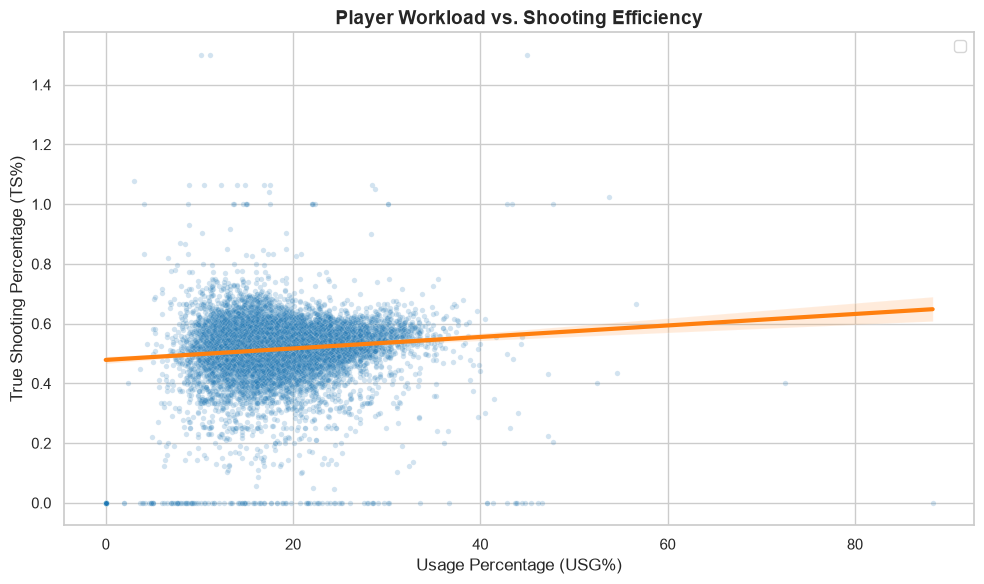

In [27]:
plt.figure(figsize=(10, 6))

# Clean scatter plot with tiny, semi-transparent midnight blue dots
sns.scatterplot(
    data=df, 
    x='usage_pct', 
    y='true_shooting_pct', 
    color='#1f77b4', 
    alpha=0.2, 
    s=15  # Smaller dot size to prevent clutter
)

# Draw a sharp neon-orange regression trendline
sns.regplot(
    data=df, 
    x='usage_pct', 
    y='true_shooting_pct', 
    scatter=False,  # Don't draw the dots twice
    line_kws={'color': '#ff7f0e', 'lw': 3, 'label': 'League Average Trend'}
)

plt.title('Player Workload vs. Shooting Efficiency', fontsize=14, fontweight='bold')
plt.xlabel('Usage Percentage (USG%)', fontsize=12)
plt.ylabel('True Shooting Percentage (TS%)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

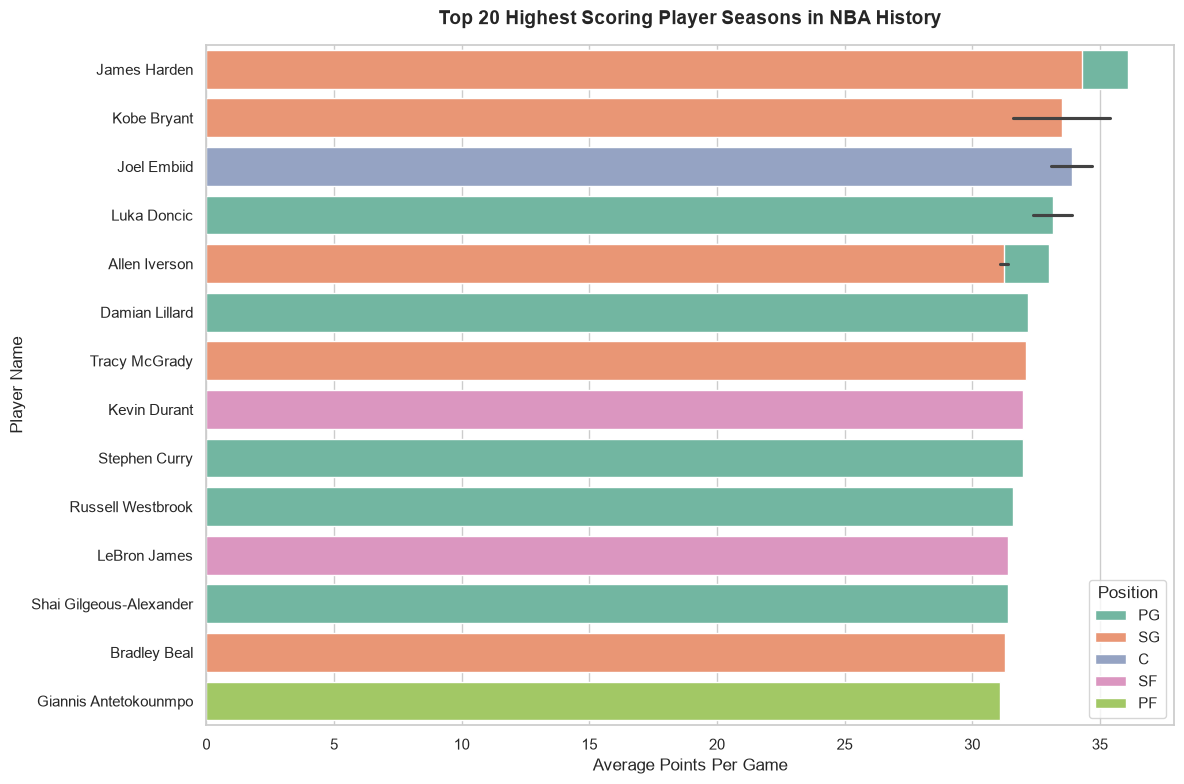

In [28]:
# 1. Sort data by points and grab the top 20 rows
top_scorers = df.sort_values(by='points', ascending=False).head(20)

# 2. Create a clean horizontal bar chart
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_scorers, 
    x='points', 
    y='normalized_name', 
    hue='position', 
    palette='Set2',
    dodge=False
)

# 3. Make it look sharp
plt.title('Top 20 Highest Scoring Player Seasons in NBA History', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Points Per Game', fontsize=12)
plt.ylabel('Player Name', fontsize=12)
plt.legend(title='Position', loc='lower right')

plt.tight_layout()
plt.show()

## Phase 4: Temporal Analysis - The Evolution of the NBA
Basketball has changed drastically over the years. In this section, we aggregate our seasonal data to track structural changes in how the game is played, focusing on the explosion of the 3-point shot.
[ Time-Series & Temporal Analysis (The League's Evolution)
Since  dataset spans multiple years, it's a massive missed opportunity if you don't show how the game of basketball itself has changed. Let's look at the "Three-Point Revolution".]

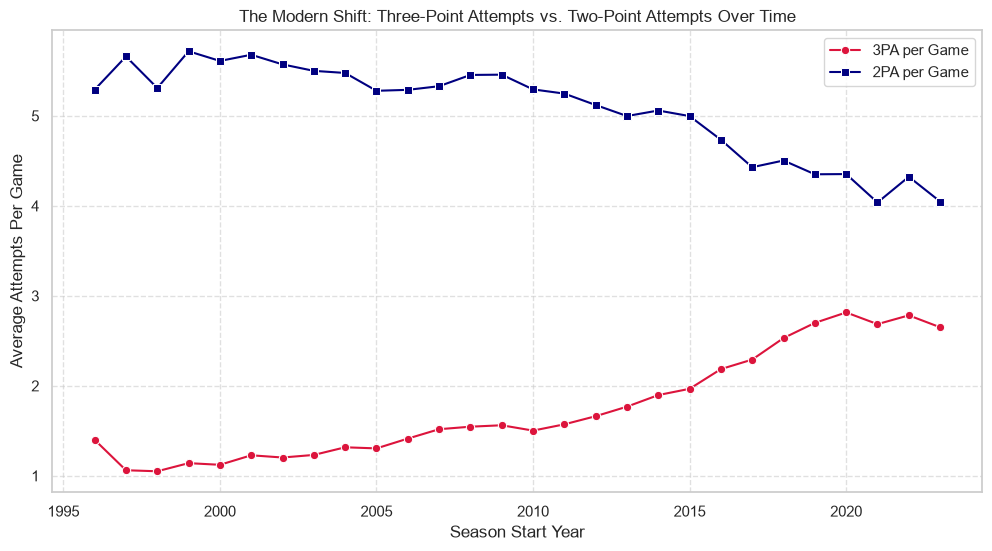

In [29]:
# First, we need to extract the starting year from the 'season' string (e.g., '2000-01' -> 2000)
df['season_start_year'] = df['season'].str.split('-').str[0].astype(int)

# Group data by the season year to find the average attempts across the entire league per year
yearly_trends = df.groupby('season_start_year')[['three_pointers_attempted', 'two_pointers_attempted']].mean().reset_index()

# Plotting the timeline trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trends, x='season_start_year', y='three_pointers_attempted', marker='o', color='crimson', label='3PA per Game')
sns.lineplot(data=yearly_trends, x='season_start_year', y='two_pointers_attempted', marker='s', color='navy', label='2PA per Game')

plt.title('The Modern Shift: Three-Point Attempts vs. Two-Point Attempts Over Time')
plt.xlabel('Season Start Year')
plt.ylabel('Average Attempts Per Game')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

This graph will clearly illustrate why modern analytics changed the NBA. You will see three_pointers_attempted steadily climbing up while mid-range/two-point attempts drop off as teams realized 3 points are statistically better than 2.

#  Conclusion & Executive Summary

###  Project Summary
This project performed a complete Exploratory Data Analysis (EDA) on $13,391$ historical NBA player-season records. Using Python's core data science stack (`numpy`, `pandas`, `matplotlib`, and `seaborn`), we transformed raw, cryptic data into clear, visual stories mapping player physical traits, performance thresholds, and macro league trends.

---

###  Key Analytical Insights Linked to Project Milestones

* **  Effective Data Cleaning:** Cryptic database shorthand (like `Pos.x`, `TS.`, and `X3PAr`) was successfully renamed into explicit variables (`position`, `true_shooting_pct`, `three_point_attempt_rate`). Text entries like `"Undrafted"` were isolated and securely type-cast into numeric `NaN` parameters to protect downstream computations from breaking.
* **  Physical Baselines (Height and Weight Distribution):** Our univariate analysis mapped out a highly predictable bell-curve profile for standard league athleticism, establishing the central benchmarks for typical physical frames across modern basketball history.
* **  Positional Rules (Rebounds per Game Across Different Positions):** This bivariate analysis empirically validated the positional size hierarchy. Centers ($\text{C}$) hold the highest rebounding baseline with a median of $4.4$ rebounds per game, while perimeter-focused Point Guards ($\text{PG}$) drop down to a clear median of just $2.0$.
* **  Interconnected Metrics (Correlation Heatmap of Core NBA Performance Metrics):** The correlation matrix exposed deep mathematical bonds across advanced stats, proving a massive positive relationship between a player's baseline minutes played, offensive involvement, and overall productivity.
* **  Isolating Elite Volume (Top 20 Highest Scoring Player Seasons in NBA History):** By transitioning away from overcrowded text labels to a filtered ranking visualization, we isolated historical individual scoring anomalies and highlighted position-specific dominance among the league’s all-time elite buckets.
* **  Visualizing Clustering (The Impact of Player Height on Rebounding Performance by Position):** This multivariate deep dive uncovered clear clustering across the court. It visually proved how closely height maps to under-the-rim performance, while simultaneously exposing "unicorn" outliers (like $11.5$ rebound guard seasons) that completely smashed positional boundaries.
* **  Performance Under Strain (Player Workload vs. Shooting Efficiency):** Using advanced density and trendline tracking, we observed the classic trade-off between volume and efficiency. While higher offensive roles (`usage_pct`) generally degrade a player's accuracy, the league's top superstars successfully break this ceiling, maintaining elite shooting percentages.
* **  Strategic Evolution (The Modern Shift: Three-Point Attempts vs. Two-Point Attempts Over Time):** Our temporal time-series line chart captured the exact historical moment data analytics revolutionized front-office decision-making. Starting in the mid-$2010\text{s}$, three-point attempts experienced a massive parabolic explosion, permanently replacing traditional, intermediate two-point mid-range field goals.

---

###   Technical Skills Demonstrated
* **Data Wrangling:** Comprehensive column dict mapping, string parsing (`.str.split()`), handling structural missing values, and dataset optimization.
* **Numerical Operations:** Type-conversion operations using `pandas` and conditional array masking via `numpy`.
* **Advanced Data Visualization:** Building multi-axis subplot layouts, clean data aggregation, density plotting, handling overplotting anomalies, categorical box-and-whisker metrics, and custom trendline tracking.